# Lesson 9: Difference-in-Differences, Synthetic Control, LDV Models, and Staggered Adoption

**Probability, Statistics, and Econometrics for Finance, Accounting, and Economics**  
**Lecture 9 of the extended econometrics sequence**

Lesson 8 introduced endogeneity and basic causal-inference tools. This lecture goes deeper into **difference-in-differences (DiD)** and related panel-data methods.

## Learning goals

By the end of this lecture, you should be able to:

1. Explain the identifying assumption behind difference-in-differences.
2. Estimate DiD models with more than two periods and more realistic simulated panel data.
3. Diagnose common DiD failures: non-parallel trends, anticipation, spillovers, treatment-effect heterogeneity, and serial correlation.
4. Understand why **two-way fixed effects** can fail under staggered treatment adoption.
5. Compare DiD to lagged dependent variable regressions.
6. Implement event-study regressions.
7. Understand the logic of synthetic control methods.
8. Simulate how different assumptions affect estimated treatment effects.

The central theme is simple:

> DiD is powerful because it removes fixed differences between groups and common time shocks. DiD fails when treated and untreated units would not have followed parallel counterfactual trends.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.optimize import minimize

np.random.seed(42)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 120)

def twfe_residualize(df, col, unit='unit', time='time'):
    """Residualize a column with respect to unit and time fixed effects."""
    x = df[col].astype(float)
    return x - x.groupby(df[unit]).transform('mean') - x.groupby(df[time]).transform('mean') + x.mean()

def fit_twfe(df, y_col, x_cols, unit='unit', time='time', cluster=True):
    y_resid = twfe_residualize(df, y_col, unit=unit, time=time)
    X_resid = pd.DataFrame({x: twfe_residualize(df, x, unit=unit, time=time) for x in x_cols})
    model = sm.OLS(y_resid, X_resid)
    if cluster:
        return model.fit(cov_type='cluster', cov_kwds={'groups': df[unit]})
    return model.fit()

## 1. The Basic Difference-in-Differences Estimator

Suppose there are two groups, treated and control, and two time periods, before and after. Let

$$
D_i =
\begin{cases}
1 & \text{if unit } i \text{ belongs to the treated group}, \\
0 & \text{if unit } i \text{ belongs to the control group}.
\end{cases}
$$

Let

$$
Post_t =
\begin{cases}
1 & \text{after the treatment begins}, \\
0 & \text{before the treatment begins}.
\end{cases}
$$

The canonical DiD regression is

$$
Y_{it} = \alpha + \delta D_i + \lambda Post_t + \tau(D_i \times Post_t) + u_{it}.
$$

The coefficient of interest is $\tau$. It equals

$$
\hat{\tau}_{DiD}
=
(\bar{Y}_{T,post} - \bar{Y}_{T,pre})
-
(\bar{Y}_{C,post} - \bar{Y}_{C,pre}).
$$

The treated group may start higher or lower than the control group. That is handled by subtracting the pre-period difference. Both groups may also be affected by common shocks. That is handled by subtracting the control group's change over time.

The key identifying assumption is **parallel trends**:

$$
E[Y_{it}(0)-Y_{i,t-1}(0)\mid D_i=1]
=
E[Y_{it}(0)-Y_{i,t-1}(0)\mid D_i=0].
$$

In words: absent treatment, the treated and control groups would have changed similarly over time.

## 2. A Simple Two-Period Simulation

We start with the simplest clean case. The treated and control groups have different levels, but the same untreated trend. The true treatment effect is known.

In [2]:
def simulate_two_period_did(n_per_group=500, treatment_effect=2.0, level_gap=1.5, common_time_shock=0.8, sigma=1.0):
    rows = []
    for treated in [0, 1]:
        for i in range(n_per_group):
            unit_fe = np.random.normal(0, 0.5)
            for post in [0, 1]:
                untreated_y = 5 + level_gap * treated + common_time_shock * post + unit_fe + np.random.normal(0, sigma)
                y = untreated_y + treatment_effect * treated * post
                rows.append({'unit': f'{treated}_{i}', 'treated': treated, 'post': post, 'y': y})
    return pd.DataFrame(rows)

df_simple = simulate_two_period_did()
df_simple.head()

,unit,treated,post,y
0,0_0,0,0,5.110093
1,0_0,0,1,6.696046
2,0_1,0,0,5.527362
3,0_1,0,1,6.327378
4,0_2,0,0,6.557041


In [3]:
means = df_simple.groupby(['treated', 'post'])['y'].mean().unstack()
did_by_hand = (means.loc[1, 1] - means.loc[1, 0]) - (means.loc[0, 1] - means.loc[0, 0])
print(means)
print(f'\nDiD by hand: {did_by_hand:.3f}')

model_simple = smf.ols('y ~ treated + post + treated:post', data=df_simple).fit()
print(model_simple.summary().tables[1])

post            0         1
treated                    
0        5.029402  5.917747
1        6.513672  9.331184

DiD by hand: 1.929
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        5.0294      0.049    102.991      0.000       4.934       5.125
treated          1.4843      0.069     21.492      0.000       1.349       1.620
post             0.8883      0.069     12.863      0.000       0.753       1.024
treated:post     1.9292      0.098     19.752      0.000       1.738       2.121


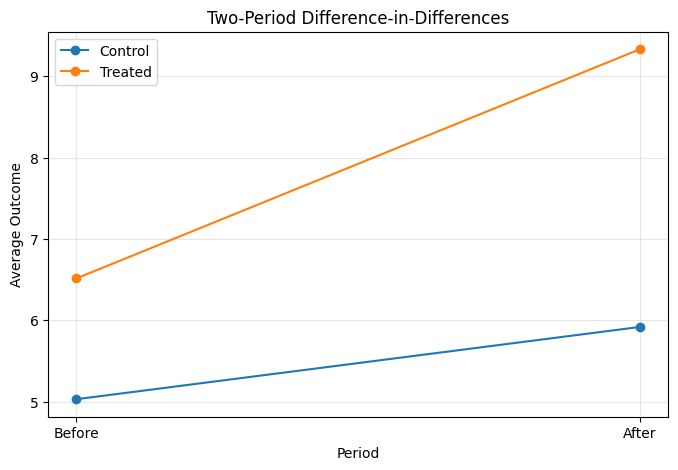

In [4]:
plot_data = df_simple.groupby(['treated', 'post'])['y'].mean().reset_index()
plot_data['group'] = np.where(plot_data['treated'] == 1, 'Treated', 'Control')

plt.figure(figsize=(8, 5))
for group, gdf in plot_data.groupby('group'):
    plt.plot(gdf['post'], gdf['y'], marker='o', label=group)
plt.xticks([0, 1], ['Before', 'After'])
plt.title('Two-Period Difference-in-Differences')
plt.ylabel('Average Outcome')
plt.xlabel('Period')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 3. Multi-Period DiD with Unit and Time Fixed Effects

Most empirical DiD designs have many periods. The standard regression becomes

$$
Y_{it} = \alpha_i + \lambda_t + \tau Treatment_{it} + u_{it}.
$$

Here, $\alpha_i$ are **unit fixed effects**, $\lambda_t$ are **time fixed effects**, and $Treatment_{it}$ equals one for treated units after treatment begins. This specification compares each unit to itself over time while removing shocks common to all units in a given period.

In [5]:
def simulate_panel_did(
    n_units=80, n_periods=12, treatment_start=7, share_treated=0.5,
    tau=2.0, trend=0.25, treated_extra_pretrend=0.0, anticipation=0.0,
    spillover=0.0, sigma_unit=1.0, sigma_time=0.5, sigma_error=1.0, seed=123):
    rng = np.random.default_rng(seed)
    units = np.arange(n_units)
    treated_units = rng.choice(units, size=int(n_units * share_treated), replace=False)
    unit_fe = rng.normal(0, sigma_unit, n_units)
    time_fe = rng.normal(0, sigma_time, n_periods)
    rows = []
    for i in units:
        treated_group = int(i in treated_units)
        for t in range(n_periods):
            post = int(t >= treatment_start)
            treatment = treated_group * post
            untreated = 10 + unit_fe[i] + time_fe[t] + trend * t + treated_extra_pretrend * treated_group * t + rng.normal(0, sigma_error)
            anticipate = anticipation * treated_group * int(t == treatment_start - 1)
            spill = spillover * (1 - treated_group) * post
            y = untreated + tau * treatment + anticipate + spill
            rows.append({'unit': i, 'time': t, 'treated_group': treated_group, 'post': post, 'treatment': treatment, 'y': y})
    return pd.DataFrame(rows)

df_panel = simulate_panel_did(treated_extra_pretrend=0.0, tau=2.0)
df_panel.head()

,unit,time,treated_group,post,treatment,y
0,0,0,1,0,0,9.844270
1,0,1,1,0,0,12.570111
2,0,2,1,0,0,11.438421
3,0,3,1,0,0,11.678996
4,0,4,1,0,0,12.319112


In [6]:
twfe_model = fit_twfe(df_panel, 'y', ['treatment'])
print(f'Estimated treatment effect: {twfe_model.params["treatment"]:.3f}')
print(f'Clustered SE: {twfe_model.bse["treatment"]:.3f}')

Estimated treatment effect: 2.079
Clustered SE: 0.117


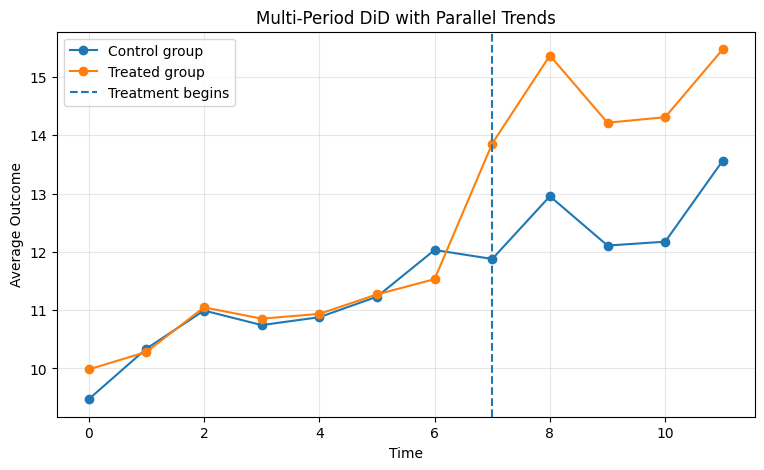

In [7]:
avg = df_panel.groupby(['time', 'treated_group'])['y'].mean().reset_index()
plt.figure(figsize=(9, 5))
for treated_group, gdf in avg.groupby('treated_group'):
    label = 'Treated group' if treated_group == 1 else 'Control group'
    plt.plot(gdf['time'], gdf['y'], marker='o', label=label)
plt.axvline(7, linestyle='--', label='Treatment begins')
plt.title('Multi-Period DiD with Parallel Trends')
plt.xlabel('Time')
plt.ylabel('Average Outcome')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 4. Event-Study DiD

A multi-period DiD can be expanded into an **event-study** specification:

$$
Y_{it} = \alpha_i + \lambda_t + \sum_{k \neq -1} \beta_k 1[t - T_i = k] + u_{it}.
$$

Here, $k$ is **event time**: the number of periods before or after treatment. The period immediately before treatment, $k=-1$, is usually omitted as the reference period.

Event studies are useful because they show whether treated and control units had similar pre-treatment trends, whether treatment effects appear before treatment begins, and how treatment effects evolve after adoption.

In [8]:
def add_event_time_columns(df, treatment_start=7, min_k=-5, max_k=4, omit_k=-1):
    df = df.copy()
    df['event_time'] = df['time'] - treatment_start
    for k in range(min_k, max_k + 1):
        if k == omit_k:
            continue
        name = f'ev_{k}'.replace('-', 'm')
        df[name] = ((df['treated_group'] == 1) & (df['event_time'] == k)).astype(int)
    return df

df_event = add_event_time_columns(df_panel, treatment_start=7)
event_cols = [c for c in df_event.columns if c.startswith('ev_')]
event_model = fit_twfe(df_event, 'y', event_cols)

event_results = []
for c in event_cols:
    k = int(c.replace('ev_', '').replace('m', '-'))
    event_results.append({'event_time': k, 'coef': event_model.params[c], 'se': event_model.bse[c]})
event_results = pd.DataFrame(event_results).sort_values('event_time')
event_results

,event_time,coef,se
0,-5,0.069775,0.264078
1,-4,0.124978,0.319747
2,-3,0.072127,0.294727
3,-2,0.053928,0.254813
4,0,1.995165,0.244912
5,1,2.428611,0.275862
6,2,2.122642,0.236812
7,3,2.150672,0.257272
8,4,1.924930,0.236104


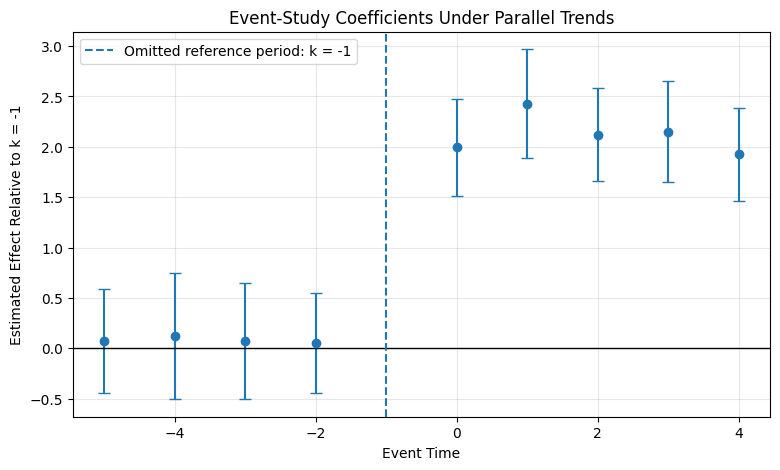

In [9]:
plt.figure(figsize=(9, 5))
plt.errorbar(event_results['event_time'], event_results['coef'], yerr=1.96 * event_results['se'], fmt='o', capsize=4)
plt.axhline(0, color='black', linewidth=1)
plt.axvline(-1, linestyle='--', label='Omitted reference period: k = -1')
plt.title('Event-Study Coefficients Under Parallel Trends')
plt.xlabel('Event Time')
plt.ylabel('Estimated Effect Relative to k = -1')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 5. What Goes Wrong? Non-Parallel Trends

The main failure mode is that treated and control units were already moving differently before treatment.

Suppose treated units would have grown faster even without the treatment:

$$
Y_{it}(0) = \alpha_i + \lambda_t + \rho t + \eta D_i t + u_{it},
$$

where $\eta \neq 0$. If we omit the treated-group-specific trend $D_i t$, then the treatment variable absorbs some of that trend. The estimated treatment effect is biased.

For a two-period design, the bias is transparent:

$$
\hat{\tau}_{DiD}
=
\tau
+
\left[
E(\Delta Y_i(0)\mid D_i=1)
-
E(\Delta Y_i(0)\mid D_i=0)
\right].
$$

The second term is the **parallel-trends violation**.

In [10]:
df_bad_trends = simulate_panel_did(treated_extra_pretrend=0.20, tau=2.0, seed=456)
bad_twfe = fit_twfe(df_bad_trends, 'y', ['treatment'])
print(f'True treatment effect: 2.000')
print(f'Estimated TWFE effect with non-parallel pre-trends: {bad_twfe.params["treatment"]:.3f}')
print(f'Clustered SE: {bad_twfe.bse["treatment"]:.3f}')

True treatment effect: 2.000
Estimated TWFE effect with non-parallel pre-trends: 3.193
Clustered SE: 0.132


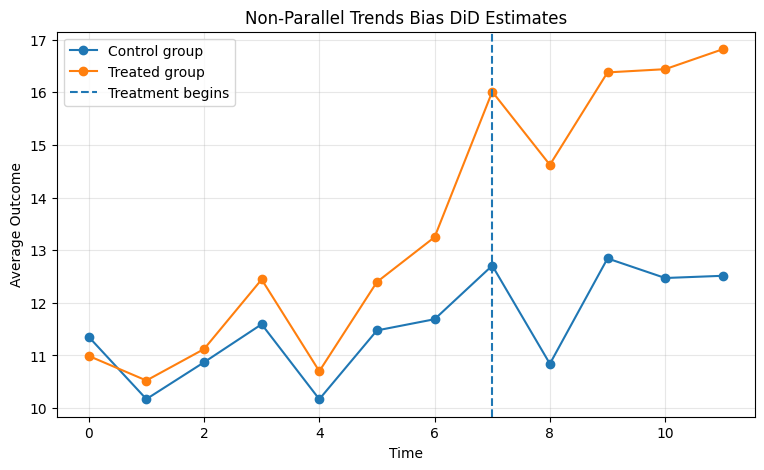

In [11]:
avg_bad = df_bad_trends.groupby(['time', 'treated_group'])['y'].mean().reset_index()
plt.figure(figsize=(9, 5))
for treated_group, gdf in avg_bad.groupby('treated_group'):
    label = 'Treated group' if treated_group == 1 else 'Control group'
    plt.plot(gdf['time'], gdf['y'], marker='o', label=label)
plt.axvline(7, linestyle='--', label='Treatment begins')
plt.title('Non-Parallel Trends Bias DiD Estimates')
plt.xlabel('Time')
plt.ylabel('Average Outcome')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

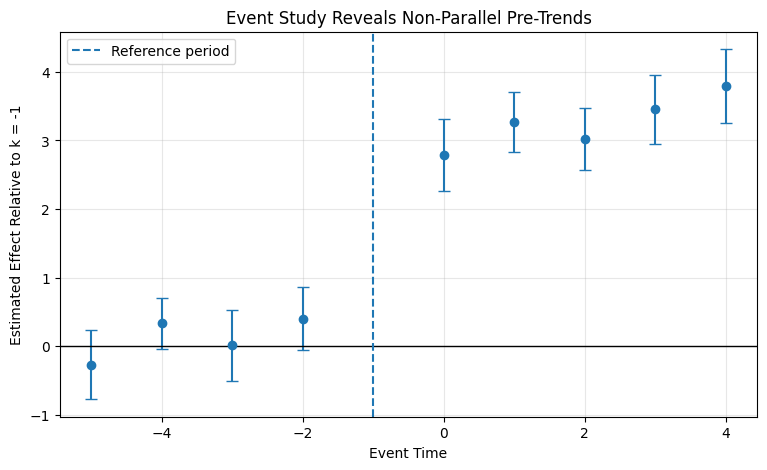

In [12]:
df_bad_event = add_event_time_columns(df_bad_trends, treatment_start=7)
event_cols_bad = [c for c in df_bad_event.columns if c.startswith('ev_')]
bad_event_model = fit_twfe(df_bad_event, 'y', event_cols_bad)

bad_event_results = []
for c in event_cols_bad:
    k = int(c.replace('ev_', '').replace('m', '-'))
    bad_event_results.append({'event_time': k, 'coef': bad_event_model.params[c], 'se': bad_event_model.bse[c]})
bad_event_results = pd.DataFrame(bad_event_results).sort_values('event_time')

plt.figure(figsize=(9, 5))
plt.errorbar(bad_event_results['event_time'], bad_event_results['coef'], yerr=1.96 * bad_event_results['se'], fmt='o', capsize=4)
plt.axhline(0, color='black', linewidth=1)
plt.axvline(-1, linestyle='--', label='Reference period')
plt.title('Event Study Reveals Non-Parallel Pre-Trends')
plt.xlabel('Event Time')
plt.ylabel('Estimated Effect Relative to k = -1')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6. Anticipation Effects

DiD assumes treatment affects outcomes only after treatment begins. But agents may change behavior before the official treatment date.

Examples include firms changing hiring before a minimum wage law, banks adjusting balance sheets before a new capital rule, or investors trading before an announced tax change. If anticipation occurs, pre-treatment periods are contaminated.

In [13]:
df_anticipation = simulate_panel_did(treated_extra_pretrend=0.0, anticipation=1.5, tau=2.0, seed=789)
anticipation_twfe = fit_twfe(df_anticipation, 'y', ['treatment'])
print(f'True post-treatment effect: 2.000')
print(f'Estimated TWFE effect with anticipation: {anticipation_twfe.params["treatment"]:.3f}')

True post-treatment effect: 2.000
Estimated TWFE effect with anticipation: 1.834


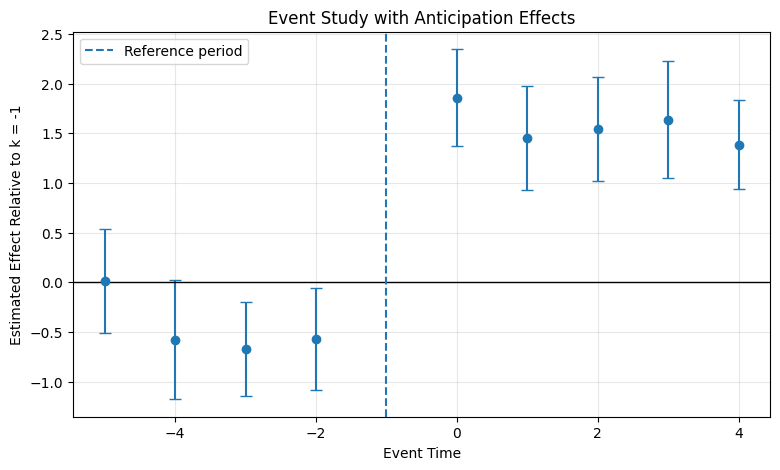

In [14]:
df_ant_event = add_event_time_columns(df_anticipation, treatment_start=7)
event_cols_ant = [c for c in df_ant_event.columns if c.startswith('ev_')]
ant_event_model = fit_twfe(df_ant_event, 'y', event_cols_ant)

ant_event_results = []
for c in event_cols_ant:
    k = int(c.replace('ev_', '').replace('m', '-'))
    ant_event_results.append({'event_time': k, 'coef': ant_event_model.params[c], 'se': ant_event_model.bse[c]})
ant_event_results = pd.DataFrame(ant_event_results).sort_values('event_time')

plt.figure(figsize=(9, 5))
plt.errorbar(ant_event_results['event_time'], ant_event_results['coef'], yerr=1.96 * ant_event_results['se'], fmt='o', capsize=4)
plt.axhline(0, color='black', linewidth=1)
plt.axvline(-1, linestyle='--', label='Reference period')
plt.title('Event Study with Anticipation Effects')
plt.xlabel('Event Time')
plt.ylabel('Estimated Effect Relative to k = -1')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 7. Spillovers and SUTVA Violations

The standard DiD interpretation also assumes untreated units are not affected by treatment. This is a version of the **Stable Unit Treatment Value Assumption**, often abbreviated SUTVA.

If controls are indirectly treated, the control-group counterfactual is contaminated. If the true treatment effect is $\tau$ and the control group receives a spillover effect $s$, the DiD contrast may estimate approximately

$$
\tau - s.
$$

In [15]:
df_spill = simulate_panel_did(spillover=0.8, tau=2.0, seed=111)
spill_twfe = fit_twfe(df_spill, 'y', ['treatment'])
print(f'True direct treatment effect: 2.000')
print(f'Control spillover after treatment: 0.800')
print(f'Estimated TWFE effect: {spill_twfe.params["treatment"]:.3f}')

True direct treatment effect: 2.000
Control spillover after treatment: 0.800
Estimated TWFE effect: 1.023


## 8. Serial Correlation and Clustered Standard Errors

Panel outcomes are often serially correlated. If we ignore this, standard errors can be too small. This is especially important in DiD because treatment often changes at the group level and persists over time.

A common practical rule:

> Cluster at the level where treatment is assigned.

Clustered standard errors allow arbitrary correlation within clusters:

$$
E[u_{it}u_{is}\mid i] \neq 0.
$$

In [16]:
ols_conventional = fit_twfe(df_panel, 'y', ['treatment'], cluster=False)
ols_clustered = fit_twfe(df_panel, 'y', ['treatment'], cluster=True)

se_compare = pd.DataFrame({
    'estimate': [ols_conventional.params['treatment'], ols_clustered.params['treatment']],
    'standard_error': [ols_conventional.bse['treatment'], ols_clustered.bse['treatment']],
}, index=['Conventional SE', 'Clustered by unit'])
se_compare

,estimate,standard_error
Conventional SE,2.078575,0.125847
Clustered by unit,2.078575,0.117401


## 9. Lagged Dependent Variable Regressions versus DiD

A common alternative to DiD is a lagged dependent variable model. In a simple post-treatment cross section, one might estimate

$$
Y_{i,post} = \alpha + \rho Y_{i,pre} + \tau D_i + u_i.
$$

This is called an **LDV regression** because it controls for the lagged dependent variable.

DiD removes fixed level differences. LDV controls for baseline outcomes. LDV can be useful when baseline outcomes strongly predict later outcomes, but it can be biased if treatment assignment is related to shocks between periods or if the lagged outcome is already affected by anticipation or earlier treatment.

In [17]:
def simulate_ldv_vs_did(n=400, tau=2.0, selection_strength=1.5, seed=42):
    rng = np.random.default_rng(seed)
    alpha_i = rng.normal(0, 1, n)
    y_pre = 5 + alpha_i + rng.normal(0, 1, n)
    prob_treat = 1 / (1 + np.exp(-(selection_strength * (y_pre - y_pre.mean()))))
    treated = rng.binomial(1, prob_treat)
    y_post = 5 + alpha_i + 0.5 + tau * treated + rng.normal(0, 1, n)
    panel = pd.DataFrame({'unit': np.repeat(np.arange(n), 2), 'post': np.tile([0, 1], n), 'treated_group': np.repeat(treated, 2), 'y': np.ravel(np.column_stack([y_pre, y_post]))})
    panel['treatment'] = panel['treated_group'] * panel['post']
    wide = pd.DataFrame({'unit': np.arange(n), 'treated': treated, 'y_pre': y_pre, 'y_post': y_post})
    return panel, wide

df_ldv_panel, df_ldv_wide = simulate_ldv_vs_did()
did_ldv = fit_twfe(df_ldv_panel.rename(columns={'post':'time'}), 'y', ['treatment'])
ldv_model = smf.ols('y_post ~ treated + y_pre', data=df_ldv_wide).fit()

print(f'True effect: 2.000')
print(f'DiD estimate: {did_ldv.params["treatment"]:.3f}')
print(f'LDV estimate: {ldv_model.params["treated"]:.3f}')

True effect: 2.000
DiD estimate: 1.039
LDV estimate: 1.995


## 10. Staggered Adoption

Many real policies are not adopted all at once. Different units adopt treatment at different times. This is called **staggered adoption**.

The traditional two-way fixed effects model is

$$
Y_{it} = \alpha_i + \lambda_t + \tau D_{it} + u_{it}.
$$

With staggered adoption and homogeneous treatment effects, this can work well. With heterogeneous or dynamic treatment effects, it may fail because already-treated units can become controls for later-treated units.

In [18]:
def simulate_staggered_adoption(n_units=120, n_periods=12, cohorts=(5, 7, 9, np.inf), cohort_probs=(0.25, 0.25, 0.25, 0.25), seed=2024, dynamic_effect=True):
    rng = np.random.default_rng(seed)
    unit_fe = rng.normal(0, 1, n_units)
    time_fe = rng.normal(0, 0.5, n_periods)
    adoption_time = rng.choice(cohorts, size=n_units, p=cohort_probs)
    rows = []
    for i in range(n_units):
        g = adoption_time[i]
        for t in range(n_periods):
            treated = int(t >= g) if np.isfinite(g) else 0
            exposure = max(0, t - g + 1) if treated else 0
            tau_it = 0.5 * exposure if dynamic_effect else (2.0 if treated else 0.0)
            y0 = 10 + unit_fe[i] + time_fe[t] + 0.20 * t + rng.normal(0, 1)
            y = y0 + tau_it
            rows.append({'unit': i, 'time': t, 'g': g, 'treated': treated, 'exposure': exposure, 'true_tau_it': tau_it, 'y': y})
    return pd.DataFrame(rows)

df_stag = simulate_staggered_adoption(dynamic_effect=True)
df_stag.head()

,unit,time,g,treated,exposure,true_tau_it,y
0,0,0,7.0,0,0.0,0.0,10.003016
1,0,1,7.0,0,0.0,0.0,10.634776
2,0,2,7.0,0,0.0,0.0,11.352692
3,0,3,7.0,0,0.0,0.0,11.218483
4,0,4,7.0,0,0.0,0.0,11.524858


In [19]:
twfe_stag = fit_twfe(df_stag, 'y', ['treated'])
true_att = df_stag.loc[df_stag['treated'] == 1, 'true_tau_it'].mean()
print(f'Average true effect among treated observations: {true_att:.3f}')
print(f'TWFE estimate under staggered adoption and dynamic effects: {twfe_stag.params["treated"]:.3f}')
print(f'Clustered SE: {twfe_stag.bse["treated"]:.3f}')

Average true effect among treated observations: 1.679
TWFE estimate under staggered adoption and dynamic effects: 1.095
Clustered SE: 0.109


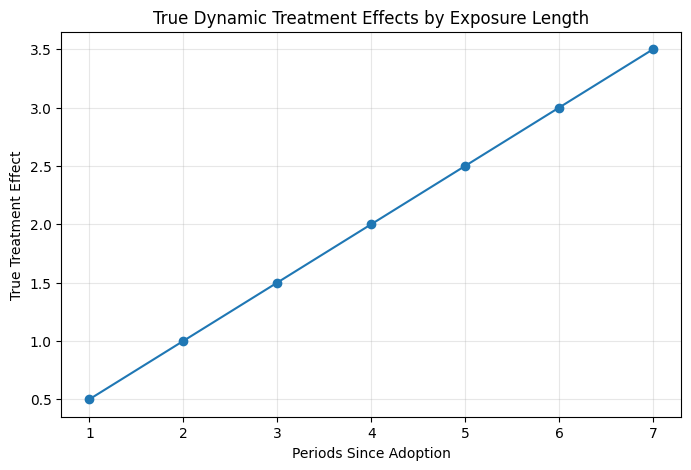

In [20]:
treated_obs = df_stag[df_stag['treated'] == 1].copy()
effect_by_exposure = treated_obs.groupby('exposure')['true_tau_it'].mean().reset_index()
plt.figure(figsize=(8, 5))
plt.plot(effect_by_exposure['exposure'], effect_by_exposure['true_tau_it'], marker='o')
plt.title('True Dynamic Treatment Effects by Exposure Length')
plt.xlabel('Periods Since Adoption')
plt.ylabel('True Treatment Effect')
plt.grid(True, alpha=0.3)
plt.show()

## 11. A Safer Staggered-Adoption Alternative: Group-Time ATT

One remedy is to estimate treatment effects by cohort and time:

$$
ATT(g,t) = E[Y_t(g)-Y_t(0)\mid G_i=g],
$$

where $G_i=g$ means unit $i$ first receives treatment in period $g$.

A simple version compares cohort $g$ to units not yet treated by time $t$. This avoids using already-treated units as controls.

For each cohort $g$ and post-treatment period $t \geq g$, define a pre-period $g-1$ and estimate

$$
\widehat{ATT}(g,t)
=
\left[
\bar{Y}_{g,t} - \bar{Y}_{g,g-1}
\right]
-
\left[
\bar{Y}_{C,t} - \bar{Y}_{C,g-1}
\right],
$$

where $C$ is the set of units untreated at time $t$.

In [21]:
def group_time_att(df):
    atts = []
    finite_cohorts = sorted([g for g in df['g'].unique() if np.isfinite(g)])
    for g in finite_cohorts:
        pre = int(g - 1)
        for t in range(int(g), df['time'].max() + 1):
            control_units = df.loc[df['g'] > t, 'unit'].unique()
            treated_units = df.loc[df['g'] == g, 'unit'].unique()
            if len(control_units) == 0 or pre < df['time'].min():
                continue
            y_treat_t = df.loc[(df['unit'].isin(treated_units)) & (df['time'] == t), 'y'].mean()
            y_treat_pre = df.loc[(df['unit'].isin(treated_units)) & (df['time'] == pre), 'y'].mean()
            y_ctrl_t = df.loc[(df['unit'].isin(control_units)) & (df['time'] == t), 'y'].mean()
            y_ctrl_pre = df.loc[(df['unit'].isin(control_units)) & (df['time'] == pre), 'y'].mean()
            att = (y_treat_t - y_treat_pre) - (y_ctrl_t - y_ctrl_pre)
            true_tau = df.loc[(df['unit'].isin(treated_units)) & (df['time'] == t), 'true_tau_it'].mean()
            atts.append({'cohort': g, 'time': t, 'event_time': t - g, 'att': att, 'true_tau': true_tau, 'n_controls': len(control_units)})
    return pd.DataFrame(atts)

att_gt = group_time_att(df_stag)
att_gt.head(10)

,cohort,time,event_time,att,true_tau,n_controls
0,5.0,5,0.0,0.517742,0.5,84
1,5.0,6,1.0,0.948207,1.0,84
2,5.0,7,2.0,1.589953,1.5,64
3,5.0,8,3.0,1.575311,2.0,64
4,5.0,9,4.0,2.226445,2.5,33
5,5.0,10,5.0,2.928427,3.0,33
6,5.0,11,6.0,3.490766,3.5,33
7,7.0,7,0.0,0.576085,0.5,64
8,7.0,8,1.0,0.913315,1.0,64
9,7.0,9,2.0,1.316649,1.5,33


In [22]:
att_avg = att_gt['att'].mean()
true_avg_gt = att_gt['true_tau'].mean()
print(f'Average group-time ATT estimate: {att_avg:.3f}')
print(f'Average true group-time effect: {true_avg_gt:.3f}')
print(f'TWFE estimate: {twfe_stag.params["treated"]:.3f}')

Average group-time ATT estimate: 1.583
Average true group-time effect: 1.633
TWFE estimate: 1.095


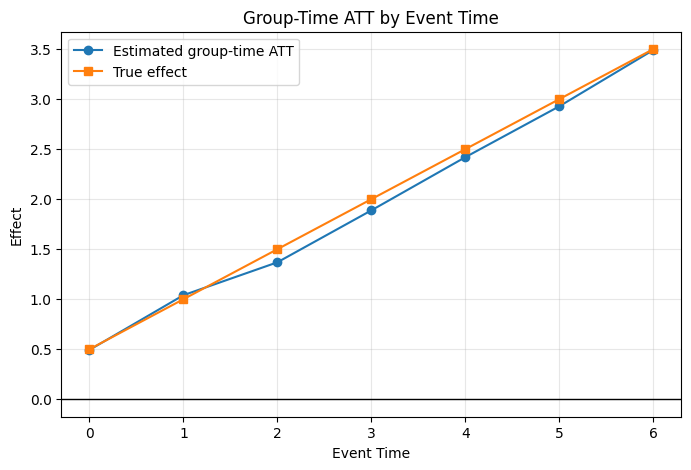

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(att_gt.groupby('event_time')['att'].mean(), marker='o', label='Estimated group-time ATT')
plt.plot(att_gt.groupby('event_time')['true_tau'].mean(), marker='s', label='True effect')
plt.axhline(0, color='black', linewidth=1)
plt.title('Group-Time ATT by Event Time')
plt.xlabel('Event Time')
plt.ylabel('Effect')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 12. Synthetic Control

Synthetic control is designed for cases with one or a few treated units and many potential controls.

Let unit 1 be treated. Let $Y_{1,pre}$ be its vector of pre-treatment outcomes. Let $Y_{0,pre}$ be a matrix of control-unit pre-treatment outcomes. Synthetic control chooses weights $w$ to solve

$$
\min_w \left\|Y_{1,pre} - Y_{0,pre}w\right\|^2
$$

subject to

$$
w_j \geq 0,
\qquad
\sum_j w_j = 1.
$$

The estimated effect after treatment is

$$
\hat{\tau}_{1t} = Y_{1t} - \sum_j w_jY_{jt}.
$$

In [24]:
def simulate_synth_control(n_controls=20, n_periods=25, treatment_start=15, tau=3.0, seed=77):
    rng = np.random.default_rng(seed)
    time = np.arange(n_periods)
    f1 = 0.3 * time
    f2 = np.sin(time / 2)
    control_loadings = rng.normal(size=(n_controls, 2))
    controls = []
    for j in range(n_controls):
        y = 5 + control_loadings[j, 0] * f1 + control_loadings[j, 1] * f2 + rng.normal(0, 0.4, n_periods)
        controls.append(y)
    controls = np.array(controls)
    true_weights = np.zeros(n_controls)
    true_weights[[2, 5, 9]] = [0.4, 0.35, 0.25]
    treated_y0 = true_weights @ controls + rng.normal(0, 0.25, n_periods)
    treated_y = treated_y0.copy()
    treated_y[treatment_start:] += tau
    rows = [pd.DataFrame({'unit': 'Treated', 'time': time, 'y': treated_y, 'treated_unit': 1})]
    for j in range(n_controls):
        rows.append(pd.DataFrame({'unit': f'Control {j}', 'time': time, 'y': controls[j], 'treated_unit': 0}))
    return pd.concat(rows, ignore_index=True), true_weights

df_sc, true_weights = simulate_synth_control()
df_sc.head()

,unit,time,y,treated_unit
0,Treated,0,5.059315,1
1,Treated,1,5.807486,1
2,Treated,2,5.710938,1
3,Treated,3,5.866393,1
4,Treated,4,5.427442,1


In [25]:
def fit_synthetic_control(df, treatment_start):
    treated = df[df['treated_unit'] == 1].sort_values('time')
    controls = df[df['treated_unit'] == 0].copy()
    control_units = sorted(controls['unit'].unique())
    y_treat_pre = treated.loc[treated['time'] < treatment_start, 'y'].values
    Y_controls_pre = np.column_stack([
        controls.loc[(controls['unit'] == u) & (controls['time'] < treatment_start), 'y'].values
        for u in control_units
    ])
    n_controls = len(control_units)
    def objective(w):
        diff = y_treat_pre - Y_controls_pre @ w
        return diff @ diff
    constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
    bounds = [(0, 1)] * n_controls
    w0 = np.ones(n_controls) / n_controls
    result = minimize(objective, w0, bounds=bounds, constraints=constraints, method='SLSQP')
    weights = result.x
    Y_controls_all = np.column_stack([
        controls.loc[controls['unit'] == u].sort_values('time')['y'].values
        for u in control_units
    ])
    synthetic_y = Y_controls_all @ weights
    return treated, synthetic_y, control_units, weights

treatment_start = 15
treated_sc, synthetic_y, control_units, weights = fit_synthetic_control(df_sc, treatment_start)
weight_table = pd.DataFrame({'unit': control_units, 'weight': weights}).sort_values('weight', ascending=False)
print('Largest synthetic-control weights:')
weight_table.head(8)

Largest synthetic-control weights:


,unit,weight
12,Control 2,2.533715e-01
19,Control 9,2.012855e-01
15,Control 5,1.823733e-01
6,Control 14,1.459440e-01
18,Control 8,1.350789e-01
8,Control 16,8.123361e-02
0,Control 0,7.132294e-04
5,Control 13,4.253635e-16


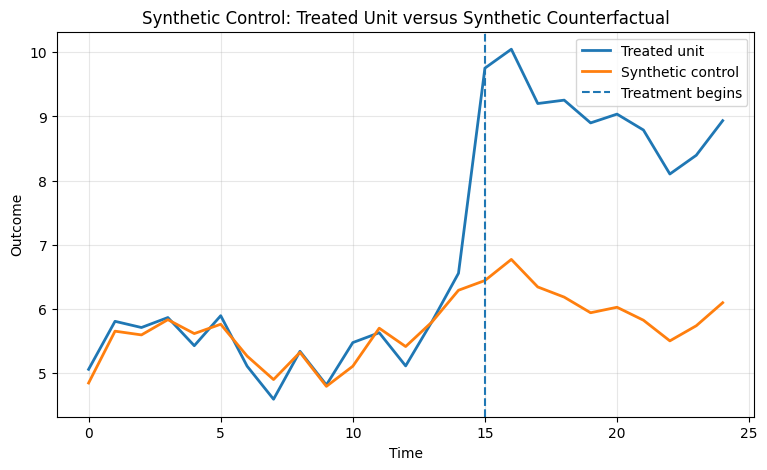

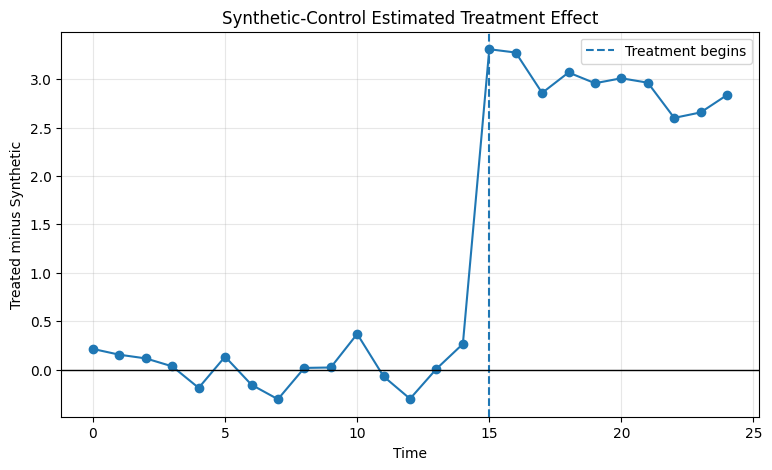

In [26]:
plt.figure(figsize=(9, 5))
plt.plot(treated_sc['time'], treated_sc['y'], label='Treated unit', linewidth=2)
plt.plot(treated_sc['time'], synthetic_y, label='Synthetic control', linewidth=2)
plt.axvline(treatment_start, linestyle='--', label='Treatment begins')
plt.title('Synthetic Control: Treated Unit versus Synthetic Counterfactual')
plt.xlabel('Time')
plt.ylabel('Outcome')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

effect_sc = treated_sc['y'].values - synthetic_y
plt.figure(figsize=(9, 5))
plt.plot(treated_sc['time'], effect_sc, marker='o')
plt.axvline(treatment_start, linestyle='--', label='Treatment begins')
plt.axhline(0, color='black', linewidth=1)
plt.title('Synthetic-Control Estimated Treatment Effect')
plt.xlabel('Time')
plt.ylabel('Treated minus Synthetic')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 13. DiD versus Synthetic Control

DiD and synthetic control share the same counterfactual logic: estimate what would have happened to treated units without treatment.

They differ in how the counterfactual is built.

### DiD

DiD assumes untreated outcomes would have followed parallel trends:

$$
E[\Delta Y(0)\mid D=1] = E[\Delta Y(0)\mid D=0].
$$

### Synthetic control

Synthetic control tries to build a weighted control group that matches the treated unit's pre-treatment path:

$$
Y_{treated,pre} \approx \sum_j w_jY_{j,pre}.
$$

Synthetic control is often more credible when there is one treated unit or a small number of treated units, many potential control units, and a long pre-treatment time series.

## 14. More DiD Problems and Practical Diagnostics

### 14.1 Composition changes

If the treated and control groups contain different people, firms, or states over time, apparent treatment effects may reflect changing composition rather than causal effects.

### 14.2 Differential shocks

If treated units are exposed to other shocks at the same time as treatment, DiD may attribute those shocks to treatment.

### 14.3 Treatment timing chosen in response to trends

If treatment is adopted because the outcome is rising or falling, treatment timing is endogenous.

### 14.4 Bad controls

Do not control for variables that are themselves affected by treatment. A post-treatment control can block part of the treatment effect or introduce collider bias.

### 14.5 Inference with few clusters

Clustered standard errors rely on large-cluster asymptotics. With few clusters, conventional cluster-robust standard errors can be unreliable. Alternatives include wild cluster bootstrap methods, randomization inference, or careful design-based inference.

### 14.6 Graph first

A DiD paper should almost always show average outcomes by group over time, event-study estimates, pre-treatment fit if using synthetic control, and sensitivity to alternative control groups and windows.

## 15. Summary

This lecture deepened the basic endogeneity discussion by focusing on panel-data causal designs.

### Main points

1. **Basic DiD** estimates a treatment effect by subtracting before-after changes in a control group from before-after changes in a treated group.
2. The key assumption is **parallel counterfactual trends**.
3. **Event studies** help diagnose pre-trends, anticipation, and dynamic treatment effects.
4. **Clustered standard errors** are essential when treatment is assigned at the unit or group level and errors are serially correlated.
5. **LDV regressions** are useful alternatives but rely on different assumptions.
6. **Staggered adoption** complicates two-way fixed effects when effects are heterogeneous or dynamic.
7. **Group-time ATT estimators** avoid using already-treated units as controls.
8. **Synthetic control** constructs a weighted counterfactual from untreated units and is especially useful when there are few treated units and many controls.
9. DiD is not a mechanical formula. It is a research design. The credibility of the estimate depends on whether the counterfactual is believable.

### Practical checklist

Before trusting a DiD estimate, ask:

- Are treated and control groups comparable before treatment?
- Do pre-treatment trends look parallel?
- Is there evidence of anticipation?
- Are control units contaminated by spillovers?
- Is treatment timing plausibly exogenous?
- Are standard errors clustered at the correct level?
- Are results robust to alternative control groups, time windows, and specifications?
- In staggered-adoption settings, does the estimator avoid forbidden comparisons?